<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT2605: Cálculo Científico I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 02: Sistemas lineales, M&eacute;todos directos</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> Thomas F&uuml;hrer y Manuel A. Sánchez | <b>Fecha:</b> 20 de Marzo, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>

</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">🎯 Objetivos de la Sesión</h3>
    <ul>
        <li>C&aacute;lculo costo computacional, efecto en tiempo.</li>
        <li>Orden experimental</li>
        <li>Eliminaci&oacute;n de Gauss / Cholesky.</li>
    </ul>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2e7d32; margin-top: 0;">👤 Identificación del Estudiante</h3>
    <p style="margin-bottom: 10px; color: #555;">Por favor, completa tus datos antes de comenzar:</p>
    <ul style="list-style-type: none; padding-left: 0; color: #333;">
        <li style="margin-bottom: 5px;"><b>📌 Nombre Completo:</b> Martín Covarrubias </li>
        <li style="margin-bottom: 5px;"><b>📌 Rol / Nº Alumno:</b> 24626023 </li>
    </ul>
    <p style="font-size: 0.85em; color: #2e7d32; margin-top: 15px; border-top: 1px solid #a5d6a7; padding-top: 5px;">
        <i>💡 Haz doble clic en esta celda para editarla con tus datos.</i>
    </p>
</div>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# INTENTO DE CONFIGURACIÓN DE ESTILO (Compatible con versiones viejas y nuevas)
try:
    plt.style.use('seaborn-v0_8-whitegrid') # Nombre nuevo (Matplotlib 3.6+)
except OSError:
    plt.style.use('seaborn-whitegrid')      # Nombre antiguo

plt.rcParams['figure.figsize'] = (10, 6)

print(f"Versión de Numpy: {np.__version__}")
print(f"Estilo usado: {plt.style.context}")

Versión de Numpy: 2.4.2
Estilo usado: <function context at 0x000002505AB0EA20>


<div class="alert-block alert-warning "; style=" border-left: 5px solid #ffc107; padding: 15px; border-radius: 5px;">
    <h2 > Costo computacional </h2>
    <h3 style="color: #d35400; margin-top: 0;">📚 Teoría:</h3>
</div>

Para facilitar el c&aacute;lculo del costo computacional de un algoritmo, contamos la cantidad de operaciones aritm&eacute;ticas.
Producto interior de dos vectores $x$, $y\in\mathbb{R}^N$
$$ 
x\cdot y = \sum_{j=1}^N x_j y_j = x_1y_1 + x_2y_2 + \ldots + x_Ny_N 
$$
Nota que para calcular la suma se requiere $N$ multiplicaciones y $N-1$ adiciones, entonces el costo computacional es</p>
$$\mathrm{costo} = 2N-1 = \mathcal{O}(N) \quad\text{cuando } N\to \infty$$


## Comparaci&oacute;n entre costo cuadr&aacute;tico $\mathcal{O}(N^2)$ y costo c&uacute;bico $\mathcal{O}(N^3)$

El costo para calcular el producto $Ax$, donde $A\in\mathbb{R}^{N\times N}$, $x\in\mathbb{R}^N$ es $\mathcal{O}(N^2)$, mientras el costo para calcular $AB$ donde $A,B\in \mathbb{R}^{N\times N}$ es $\mathcal{O}(N^3)$.

Si se supone que cada operaci&oacute;n aritm&eacute;tica toma el mismo tiempo, el costo computacional se refleja directamente en el tiempo para ejecutar un algoritmo.

In [4]:
import numpy as np
import time # para medir tiempo

# Repetimos los calculos M veces (tomando los promedios)
M = 10

## MATRIZ - VECTOR
n = 13
tiempoMatVec = np.zeros(n) 
for k in range(M):
    # para N = 2^0, 2^1, 2^2, ..., 2^{n-1} medimos el tiempo para determinar el producto interior
    for j in range(n):
        N = 2**j
        # Generar vector con valores aleatorias
        x = np.random.rand(N)
        # Generar matrices NxN
        A = np.random.rand(N, N)
        
        # Ax
        tInicio = time.perf_counter()
        tmp = A@x
        tFin = time.perf_counter()
        tiempoMatVec[j] = tiempoMatVec[j]+tFin-tInicio
    
# Tomar los promedios
tiempoMatVec = tiempoMatVec/M
N_MatVec = [2**j for j in range(n)] # usamos despues

## MATRIZ - MATRIZ
n = 10
tiempoMatMat = np.zeros(n)

for k in range(M):
    # para N = 2^0, 2^1, 2^2, ..., 2^{n-1} medimos el tiempo para determinar el producto interior

    for j in range(n):
        N = 2**j
        # Generar matrices NxN
        A = np.random.rand(N, N)
        B = np.random.rand(N, N)
    
        # AB
        tInicio = time.perf_counter()
        tmp = A@B
        tFin = time.perf_counter()
        tiempoMatMat[j] = tiempoMatMat[j]+tFin-tInicio

# Tomar los promedios
tiempoMatMat = tiempoMatMat/M

N_MatMat = [2**j for j in range(n)] # usamos despues
print(tiempoMatVec)
print(tiempoMatMat)


[6.41199935e-05 9.56999720e-06 3.77999968e-06 4.17998526e-06
 3.00999382e-06 8.91999225e-06 4.85999044e-06 1.13099872e-05
 4.19699878e-05 2.30990001e-04 5.95799997e-04 2.06440001e-03
 8.61185001e-03]
[1.27579988e-04 7.63000571e-06 2.12000450e-06 2.71999161e-06
 2.54001352e-06 5.86002134e-06 1.42300036e-05 2.11679999e-04
 6.57830009e-04 4.52216001e-03]


### Visualicaci&oacute;n de los resultados

Para visualizar el tiempo, usaremos un plot doble-logar&iacute;tmico

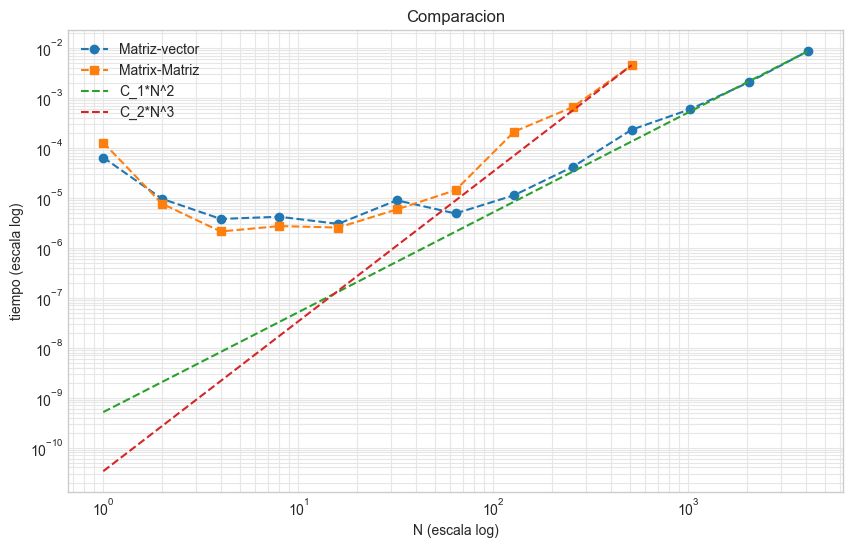

In [5]:
plt.loglog(N_MatVec, tiempoMatVec, marker='o', linestyle='--',label="Matriz-vector") 
plt.loglog(N_MatMat, tiempoMatMat, marker='s', linestyle='--',label="Matrix-Matriz") 
plt.loglog(N_MatVec, [tiempoMatVec[-1]/(N_MatVec[-1]**2)*j**2 for j in N_MatVec], linestyle='--',label="C_1*N^2") 
plt.loglog(N_MatMat, [tiempoMatMat[-1]/(N_MatMat[-1]**3)*j**3 for j in N_MatMat], linestyle='--',label="C_2*N^3") 
plt.xlabel("N (escala log)")
plt.ylabel("tiempo (escala log)")
plt.title("Comparacion")
plt.grid(True, which="both", ls="-", color='0.9') # Add major and minor gridlines
plt.legend()

### El orden experimental

El orden experimental $\alpha$ se puede determinar de la siguiente manera:

Asumimos $f(N) = \mathcal{O}(N^\alpha)$ para $N\to \infty$. Tenemos los datos $(N_j,f(N_j))$, $j=1,2,\ldots,K$.

Ahora consideramos $(\log(N_j),\log(f(N_j)))$ y tenemos que $\log(f(N_j)) \approx \alpha \log(N_j)$ seg&uacute;n suposici&oacute;n. 

El orden experimental $\alpha_j$ se obtiena al calcular la pendiente de la recta que conecta $(\log(N_{j-1}),\log(f(N_{j-1})))$ y $(\log(N_j),\log(f(N_j)))$. Es decir, 
$$\alpha_j = \frac{\log(f(N_j))-\log(f(N_{j-1}))}{\log(N_j)-\log(N_{j-1})}, \quad j=2,...,K.$$


In [18]:
import numpy as np
import pandas as pd

print("Tiempo para calcular producto matricial A*B")

difLogN = np.log(N_MatMat[1:])-np.log(N_MatMat[:-1])
difLogFN = np.log(tiempoMatMat[1:])-np.log(tiempoMatMat[:-1])
alpha = np.concatenate(([0], difLogFN / difLogN))


df_round = pd.DataFrame({
    "N": N_MatMat,
    "tiempo": tiempoMatMat, 
    "orden experimental": np.round(alpha, 2)
})

# display() formatea la tabla mucho mejor que print() en Jupyter
display(df_round)

Tiempo para calcular producto matricial A*B


,N,tiempo,orden experimental
0,1,0.000128,0.00
1,2,0.000008,-4.06
2,4,0.000002,-1.85
3,8,0.000003,0.36
4,16,0.000003,-0.10
5,32,0.000006,1.21
6,64,0.000014,1.28
7,128,0.000212,3.89
8,256,0.000658,1.64
9,512,0.004522,2.78


## Descomposici&oacute;n de Cholesky

En Python (NumPy) el comando <code>np.linalg.cholesky(A)</code> determina la descomposici&oacute;n de Cholesky de una matriz $A\in\mathbb{R}^{N\times N}$

In [29]:
# matriz:
A = np.zeros([3,3])
A[0,0] = 2
A[0,1] = -1
A[1,0] = -1
A[1,1] = 2
A[1,2] = -1
A[2,1] = -1
A[2,2] = 2

# Determinar el factor L
L = np.linalg.cholesky(A)

# Verificar
print(L@L.T-A) # nota: no usar '*' para multiplicar dos matrices! se usa '@'

print(A)
n=A.shape[0] #Cantidad de filas (o columnas, ya que es cuadrada)
for a in range(1,n+1):
    Ak = A[:a,:a]
    print(f"Submatriz principal {a}x{a}")
    print(Ak)
    print(f"El determinante es: {np.linalg.det(Ak)}\n")

[[ 4.4408921e-16  0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00 -4.4408921e-16  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  0.0000000e+00]]
[[ 2. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  2.]]
Submatriz principal 1x1
[[2.]]
El determinante es: 2.0

Submatriz principal 2x2
[[ 2. -1.]
 [-1.  2.]]
El determinante es: 2.9999999999999996

Submatriz principal 3x3
[[ 2. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  2.]]
El determinante es: 4.0



Si la matriz no es definida positiva se genera un error:

In [30]:
B = np.zeros([2,2])
B[0,0] = 1
print(np.linalg.eigvals(B)) #valores propios no son estrictamente positivos, no es positiva definida
print(np.linalg.eigvals(np.zeros([2,2]))) 
print(np.linalg.cholesky(B))

[1. 0.]
[0. 0.]


LinAlgError: Matrix is not positive definite

### Resolver un sistema lineal $Ax=b$ con Cholesky

Sea $A = LL^\top \in \mathbb{R}^{N\times N}$ invertible (descomposici&oacute;n Cholesky) y $b\in\mathbb{R}^N$. 
Para resolver el sistema $Ax = b$ necesitamos 2 pasos a parte de calcular $L$:

1. *Sustituci&oacute;n progresiva*: Resolver $Ly = b$
2. *Sustituci&oacute;n regresiva*: Resolver $L^\top x = y$

In [31]:
# Forward and Backward substitution
def forward_substitution(L,b):
    '''
    Forward substitution algorithm for system L y = b
    input : L lower triangular matrix n x n
            b vector n x 1
    output: y solution of L y = b
    '''
    n = L.shape[0]; y = np.zeros(n)
    y[0] = b[0]/L[0,0]
    for i in range(1,n):
        y[i] = (b[i] - np.dot(L[i,0:i],y[0:i]))/L[i,i]
    return y
def backward_substitution(U,y):
    '''
    Backward substitution algorithm for system U x = y
    input : U upper triangular matrix n x n
            y vector n x 1
    output : x solution of U x = y
    '''
    n = U.shape[0]; x = np.zeros(n)
    x[n-1] = y[n-1]/U[n-1,n-1]
    for i in range(n-2,-1,-1):
        x[i] = (y[i] - np.dot(U[i,(i+1):n],(x[(i+1):n])))/U[i,i]
    return x

In [32]:
# Ejemplo 
# definir matriz:
A = np.zeros([3,3])
A[0,0] = 2
A[0,1] = -1
A[1,0] = -1
A[1,1] = 2
A[1,2] = -1
A[2,1] = -1
A[2,2] = 2

# vector b 
b = np.ones(3)

# Paso 1: A = L*L^T
L = np.linalg.cholesky(A)

# Paso 2: L*y = b
y = forward_substitution(L,b)

# Paso 3: L^T*x = y
x = backward_substitution(L.T,y)

# Verificar resultado
print(A@x-b)

[-8.88178420e-16  1.55431223e-15 -4.44089210e-16]


## Eliminacion Gaussiana

- **Eliminacion Gaussiana sin pivoteo**  `` GE ``
- **Factorizacion A = LU sin pivoteo**  ``LU``

- **Eliminacion Gaussiana con pivoteo parcial** ``GEPP``
- **Factorizacion LU, PA=LU, sin pivoteo**  ``LUPP``

- **Eliminacion Gaussiana con pivoteo completo** ``GECP``
- **Factorizacion LU. PAQ = LU, con pivoteo completo**  ``LUCP``

In [33]:
# generate permutation matrix
def perm(rowpiv):
    n = rowpiv.size+1
    P = np.eye(n)
    for k in range(n-1):
        P[[k,rowpiv[k]],:] = P[[rowpiv[k], k],:]
    return P
def permb(b, rowpiv):
    n = b.size
    for k in range(n-1):
        b[[k, rowpiv[k]]] = b[[rowpiv[k],k]] 
    return b

In [37]:
# 1.
def GE(Ainput, binput):
    '''¡
    Eliminacion Gaussiana sin pivoteo
    Input : A nonsingular and square matrix n x n 
            b vector n x 1
    Output: x solution of the system A x = b
    '''
    A = Ainput.copy() # se va a modificar
    b = binput.copy() # se va a modificar
    # 1. Factorize A = LU
    L, U = LU(A)
    # 2. Solve LUx = b forward substitution
    y = forward_substitution(L, b)
    # 3. Solve Ux = L^{-1} b backward substitution
    x = backward_substitution(U,y)
    return x
def LU(Ainput):
    '''
    Factorizacion A = LU, sin pivoteo
    Input : A nonsingular and square matrix n x n 
    Output: L triangular inferior, U triangular superior, square matrix n x n
    '''
    A = Ainput.copy() # se va a modificar
    n = A.shape[0]
    for i in range(n-1):
        if A[i, i] == 0:
            raise ValueError("coeficient is zero.")
        A[(i+1):n,i] = (A[(i+1):n,i]/A[i,i])
        A[(i+1):n, (i+1):n][:] = A[(i+1):n, (i+1):n]-np.outer(A[(i+1):n,i],A[i, (i+1):n])
    L = np.tril(A,-1)+np.eye(n)
    U = np.triu(A)
    return L, U

# 2.
def GEPP(Ainput, binput):
    A = Ainput.copy() # se va a modificar
    b = binput.copy() # se va a modificar
    '''
    Eliminacion Gaussiana con pivoteo de filas o pivoteo parcial
    Input : A matriz cuadrada no singular de n x n 
            b vector de n x 1
    Output: x solucion del sistema lineal  A x = b
    '''
    # 1. Factorize A = PLU
    L, U, pT = LUPP(A)
    # 2. Solve P L U x = b
    P = perm(pT)
    rhs  = perm(pT).dot(b)
    # 3. Solve LUx = Pt b forward substitution
    y = forward_substitution(L, rhs)
    # 4. Solve Ux = L^{-1} Pt b backward substitution
    x = backward_substitution(U,y)
    return x

def LUPP(Ainput):
    '''
    Factorizacion PA = LU, con pivoteo parcial
    Input : A matriz cuadrada no singular de n x n
    Output: L triangular inferior, matriz cuadrada de n x n
            U trangular superior, matriz cuadrada de n x n
            p, vector asociado a la matriz de permutacion
    '''
    A = Ainput.copy() # se va a modificar
    n = A.shape[0]
    piv = np.arange(0,n-1)
    for i in range(n-1):
        imax = abs(A[i:,i]).argmax() + i
        piv[i] = imax
        if A[imax, i] == 0:
            raise ValueError("Matrix is singular.")
        elif imax != i:
            A[[i,imax],:] = A[[imax, i],:][:]
        A[(i+1):n,i][:] = (A[(i+1):n,i]/A[i,i])[:]
        A[(i+1):n, (i+1):n][:] = A[(i+1):n, (i+1):n]-np.outer(A[(i+1):n,i],A[i, (i+1):n])
    
    L = np.tril(A,-1)+np.eye(n)
    U = np.triu(A)
    return L, U, piv

# 
def GECP(Ainput, binput):
    '''
    Eliminacion Gaussiana con pivoteo de filas y columnas o pivoteo completo
    Input : A matriz cuadrada no singular de n x n 
            b vector de n x 1
    Output: x solucion del sistema lineal  A x = b
    '''
    A = Ainput.copy() # se va a modificar
    b = binput.copy() # se va a modificar
    # 1. Factorize PAQ^T = LU
    L, U, rowpiv, colpiv = LUCP(A)
    # 2. Solve  L U x = P b Q^T
    rhs  = perm(rowpiv).dot(b)
    # 3. Solve LUx = Pt b forward substitution
    y = forward_substitution(L, rhs)
    # 4. Solve Ux = L^{-1} Pt b backward substitution
    x = backward_substitution(U,y)
    return (perm(colpiv).T).dot(x)

def LUCP(Ainput):
    '''
    Factorizacion P A Q = L U, con pivoteo completo
    Input : A matriz cuadrada no singular de n x n
    Output: L triangular inferior, matriz cuadrada de n x n
            U trangular superior, matriz cuadrada de n x n
            p, vector asociado a la matriz de permutacion por filas
            q, vector asociado a la matriz de permutacion por columnas
    '''
    A = Ainput.copy() # se va a modificar
    n = A.shape[0]
    rowpiv = np.arange(0,n-1)
    colpiv = np.arange(0,n-1)
    for i in range(n-1):
        mu, lam = np.unravel_index(np.argmax(np.abs(A[i:,i:]), axis=None), A[i:,i:].shape)
        mu +=i; lam+=i
        if A[mu, lam] == 0:
            raise ValueError("Matrix is singular.")
        else:
            rowpiv[i] = mu
            A[[i, mu],:] = A[[mu, i],:][:]
            colpiv[i] = lam
            A[:,[i, lam]] = A[:,[lam, i]][:]
        A[(i+1):n,i] *= 1.0/A[i,i]
        A[(i+1):n, (i+1):n] -=np.outer(A[(i+1):n,i],A[i, (i+1):n])
    L = np.tril(A,-1)+np.eye(n)
    U = np.triu(A)
    return L, U, rowpiv, colpiv

In [38]:
def Eliminacion_Gaussiana(A,b, pivoteo=None):
    if pivoteo is None:
        x = GE(A,b)
    elif pivoteo == 'parcial':
        x = GEPP(A,b)
    elif pivoteo == 'completo':
        x = GECP(A,b)
    return x

def Factorizacion_LU(A, pivoteo=None):
    if pivoteo is None:
        L,U = LU(A)
        return L,U
    elif pivoteo == 'parcial':
        L,U,piv = LUPP(A)
        return L, U, piv
    elif pivoteo == 'completo':
        L, U, rowpiv, colpiv = LUCP(A)
        return  L, U, rowpiv, colpiv

def Eliminacion_Gaussiana_con_pivoteo_directa(Ainput, binput):
    # A = np.hstack((Ainput.copy(),binput.copy().reshape(n))
    A = np.c_[Ainput.copy(),binput.copy()]
    print(A)
    n = A.shape[0]
    for i in range(n-1):
        imax = abs(A[i:,i]).argmax() + i
        if A[imax, i] == 0:
            raise ValueError("Matrix is singular.")
        elif imax != i:
            A[[i,imax],:] = A[[imax, i],:][:]
        A[(i+1):n,i][:] = (A[(i+1):n,i]/A[i,i])[:]
        A[(i+1):n, (i+1):(n+1)][:] = A[(i+1):n, (i+1):(n+1)]-np.outer(A[(i+1):n,i],A[i, (i+1):(n+1)])
    if A[n-1,n-1]==0: 
        raise ValueError("Matrix is singular.")
    else:
        x = np.zeros(n)
        x[n-1] = A[n-1,n]/A[n-1,n-1]
        for i in range(n-2,-1,-1):
            x[i] = (A[i,n] - np.dot(A[i,(i+1):n],(x[(i+1):n])))/A[i,i]
    return x
    

## Ejemplo: Factorizacion LU

Encuentre la factorizacion LU de la siguiente matriz usando los algoritmos de Eliminacion Gaussiana, i) sin pivoteo, ii) con pivoteo parcial, iii) con pivoteo completo. Compare las matrices:
\begin{equation}
LU = A,\qquad 
A = \begin{bmatrix}
1 & 3 & 4 & 1\\
2 & 1 & 5 & 1 \\
3 & 1 & 6 & 1 \\
6 & 2 & 3 & 2
\end{bmatrix},
\end{equation}

In [43]:
A = np.array([[1,3,4,1],[2,1,5,1],[3,1,6,1],[6,2,3,2]],dtype=np.float64)

In [41]:
L, U = Factorizacion_LU(A, pivoteo=None)
print("L :\n", L)
print("U :\n", U)

L :
 [[1.  0.  0.  0. ]
 [2.  1.  0.  0. ]
 [3.  1.6 1.  0. ]
 [6.  3.2 9.5 1. ]]
U :
 [[ 1.   3.   4.   1. ]
 [ 0.  -5.  -3.  -1. ]
 [ 0.   0.  -1.2 -0.4]
 [ 0.   0.   0.   3. ]]


In [44]:
L, U, p = Factorizacion_LU(A, pivoteo='parcial')
print("L :\n", L)
print("U :\n", U)
print(p)

L :
 [[1.         0.         0.         0.        ]
 [0.16666667 1.         0.         0.        ]
 [0.5        0.         1.         0.        ]
 [0.33333333 0.125      0.79166667 1.        ]]
U :
 [[6.         2.         3.         2.        ]
 [0.         2.66666667 3.5        0.66666667]
 [0.         0.         4.5        0.        ]
 [0.         0.         0.         0.25      ]]
[3 3 2]


In [45]:
L, U,p,q = Factorizacion_LU(A, pivoteo='completo')
print("L :\n", L)
print("U :\n", U)
print(p,q)

L :
 [[ 1.          0.          0.          0.        ]
 [ 0.5         1.          0.          0.        ]
 [ 0.66666667 -0.22222222  1.          0.        ]
 [ 0.83333333 -0.11111111  0.125       1.        ]]
U :
 [[6.         3.         1.         1.        ]
 [0.         4.5        1.5        1.5       ]
 [0.         0.         2.66666667 0.66666667]
 [0.         0.         0.         0.25      ]]
[2 3 2] [2 2 2]


## Ejemplo: inestabilidad sin pivoteo

\begin{equation}
A = \begin{bmatrix}
0 & 1 \\
1 & 1
\end{bmatrix}, \quad \text{Eliminacion Gaussiana falla en el primer paso con } \kappa(A) = (3+\sqrt{5})/2
\end{equation}

\begin{equation}
\tilde{A} = \begin{bmatrix}
10^{-20} & 1 \\
1 & 1
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 \\
10^{20} & 1
\end{bmatrix}
\begin{bmatrix}
10^{-20} & 1 \\
0 & 1-10^{20}
\end{bmatrix}, \quad \text{Eliminacion Gaussiana ahora no falla}
\end{equation}

In [47]:
Afalla = np.array([[0,1],[1,1]], dtype=np.float64)
Atilde = np.array([[10**(-20), 1],[1,1]], dtype=np.float64)

In [48]:
L,U = Factorizacion_LU(Afalla)


ValueError: coeficient is zero.

In [50]:
L,U = Factorizacion_LU(Atilde)
print(L)
print(U,"\n")
print(L@U- Atilde)

[[1.e+00 0.e+00]
 [1.e+20 1.e+00]]
[[ 1.e-20  1.e+00]
 [ 0.e+00 -1.e+20]] 

[[ 0.  0.]
 [ 0. -1.]]


In [21]:
b = np.array([1,0])
xtilde = Eliminacion_Gaussiana(Atilde,b)
print("solucion calculada:", xtilde)
print("la solucion exacta es x = [-1,1]!")

solucion calculada: [0. 1.]
la solucion exacta es x = [-1,1]!


**Nota** La factorizacion LU es estable, no backward stable. Pero al usar eliminacion Gaussiana sin pivoteo para resolver $Ax=b$ no lo hace estable.

En general, si un paso del algoritmo es estable pero backward stable para resolver un subproblema, entonces la estabilidad del algortimo puede estar en peligro.

**Nota** Complejidad:  eliminacion Gaussiana sin pivoteo tiene costo computacional de $\approx \frac{2}{3} m^{3}$

## Ejemplo: worst case instability

### Inestabilidad

Para ciertas matrices $A$ a pesar de los efectos beneficiosos de pivotear, el factor de crecimiento $\rho$ se vuelve gigante. Por ejemplo, suponga que la matriz $A$ tiene la siguiente forma:

$$
A = \begin{bmatrix}
1 & 0 & 0 & 0 & 1 \\
-1 &1 &0 & 0& 1 \\
-1& -1 &1 & 0 &1\\
-1&-1 &-1 & 1 & 1 \\
-1& -1 &-1 &-1 &1
\end{bmatrix}
$$

En este caso, la factorization da 

$$
U = \begin{bmatrix}
 1. & 0. & 0. & 0.&  1.\\
 0. & 1. & 0. & 0.&  2.\\
 0. & 0. & 1. & 0.&  4.\\
 0. & 0. & 0. & 1.&  8.\\
 0. & 0. & 0. & 0.& 16.
 \end{bmatrix}
$$

para esta matriz de $n\times n$, con $n=5$, el factor de crecimiento es $\rho = 2^{n-1} = 16$.

Un factor de crecimiento de orden $2^{n}$ corresponde a una perdida del orden de $n$ bits de precision, lo cual es catastrofico para computaciones practicas. Como un computador standard representa numeros de punto flotante con solo 64 bits, con matries de dimensiones en cientos y miles en dimension perder m bits de precision es intolerable.

In [51]:
n = 4
A_wc = -np.tril(np.ones((n,n)),-1)+np.eye(n)
A_wc[:,-1] = np.ones(n)
A_wc

array([[ 1.,  0.,  0.,  1.],
       [-1.,  1.,  0.,  1.],
       [-1., -1.,  1.,  1.],
       [-1., -1., -1.,  1.]])

In [52]:
L, U, pT = Factorizacion_LU(A_wc, pivoteo='parcial')
U

array([[1., 0., 0., 1.],
       [0., 1., 0., 2.],
       [0., 0., 1., 4.],
       [0., 0., 0., 8.]])

In [53]:
L, U, pT, q = Factorizacion_LU(A_wc, pivoteo='completo')
U

array([[ 1.,  1.,  0.,  0.],
       [ 0.,  2.,  1.,  0.],
       [ 0.,  0., -2.,  1.],
       [ 0.,  0.,  0., -2.]])

In [54]:
e1 = []; e2 = []; e3 = []; e4 = []; N = [5*i for i in range(1,8)]
for nn in N:
    A_wc = -np.tril(np.ones((nn,nn)),-1)+np.eye(nn); A_wc[:,-1] = np.ones(nn)    
    x = np.random.rand(nn); b = A_wc.dot(x)

    x_gepp = Eliminacion_Gaussiana(A_wc, b, pivoteo='parcial')
    x_gecp = Eliminacion_Gaussiana(A_wc, b, pivoteo='completo')

    e1.append(np.linalg.norm(x-x_gepp))
    e2.append(np.linalg.norm(x-x_gecp))
    e3.append(np.linalg.norm(b-A_wc.dot(x_gepp)))
    e4.append(np.linalg.norm(b-A_wc.dot(x_gecp)))

dferror = {'n':N, '||x-x_gepp||':e1, '||x-x_gecp||':e2, '||b-A x_gepp||':e3, '||b - A x_gecp||':e4}
df = pd.DataFrame(data=dferror)
df

,n,||x-x_gepp||,||x-x_gecp||,||b-A x_gepp||,||b - A x_gecp||
0,5,2.220446e-16,0.000000e+00,4.965068e-16,0.000000e+00
1,10,1.405105e-15,3.002225e-16,2.923704e-15,9.930137e-16
2,15,8.405408e-13,4.311058e-16,1.193345e-12,1.542371e-15
3,20,1.507691e-11,9.002396e-16,2.816413e-11,2.475075e-15
4,25,4.483071e-10,1.338038e-15,1.092075e-09,2.310224e-15
5,30,1.870103e-08,2.464001e-15,2.837918e-08,7.551149e-15
6,35,1.935860e-07,3.367931e-15,3.338271e-07,8.748952e-15


---
<div class="alert alert-block alert-success"> 

## Evaluaci&oacute;n:

</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Pregunta 1</h3>
    <p>La pregunta se enuncia durante el laboratorio</p>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

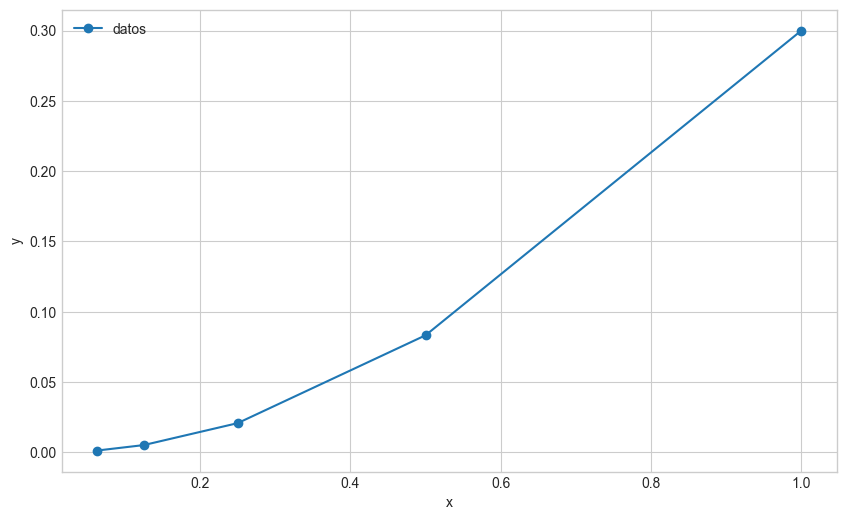

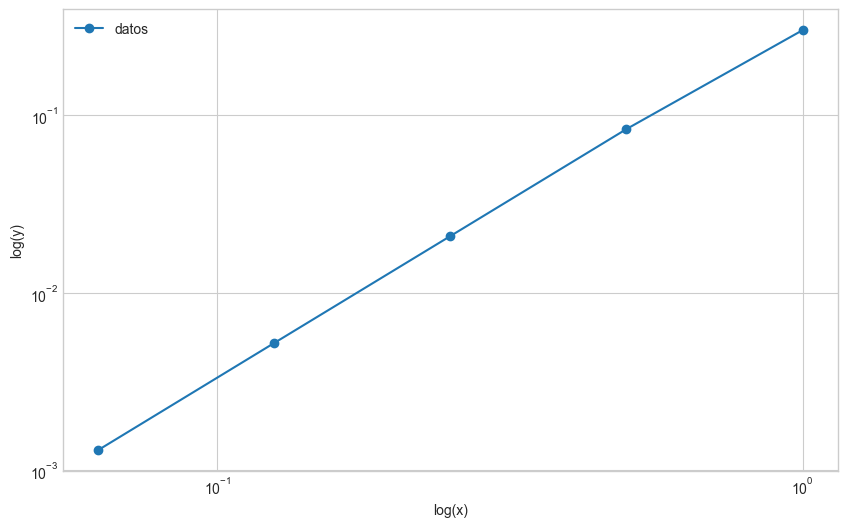

In [60]:
# Datos dados
x = np.array([1,1/2,1/4,1/8,1/16])
y = np.array([0.3,0.0833,0.02082,0.00521,0.0013])

# Solucion: Espacio para tu codigo
x = np.array([1,1/2,1/4,1/8,1/16])
y = np.array([0.3,0.0833,0.02082,0.00521,0.0013])

plt.plot(x, y, 'o-', label='datos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


plt.loglog(x, y, 'o-', label='datos')
plt.xlabel('log(x)')
plt.ylabel('log(y)')
plt.legend()
plt.show()

In [ ]:
logx = np.log(x)
logy = np.log(y)
#Usamos la ide de antes, es como si fuera una recta en el plano log log, y con eso sacamos la ecuación de la recta
difLogX = logx[1:] - logx[:-1]
difLogY = logy[1:] - logy[:-1]

alpha = difLogY / difLogX

print(alpha)

[1.8485741  2.00034643 1.99861479 2.00277175]


<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Pregunta 2</h3>
    <p>La pregunta se enuncia durante el laboratorio</p>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [62]:
A = np.array([[1,3,4,1],[2,1,5,1],[3,1,6,1],[6,2,3,2]])
b = np.array([1,0,1,1])

# Solucion: Espacio para tu codigo
# Resolver el sistema lineal A x = b
x = np.linalg.solve(A, b)

# Mostrar la solución
print("Solución x:")
print(x)

# Verificar que A @ x sea aproximadamente igual a b
print("\nVerificación A @ x:")
print(A @ x)

# Calcular el residuo r = b - A x
residuo = b - A @ x
print("\nResiduo b - A @ x:")
print(residuo)

# Calcular la norma del residuo para medir qué tan buena es la solución
norma_residuo = np.linalg.norm(residuo)
print("\nNorma del residuo:")
print(norma_residuo)

# Calcular el número de condición de A
# Esto indica qué tan sensible es la solución a perturbaciones en los datos
kappa = np.linalg.cond(A)
print("\nNúmero de condición kappa(A):")
print(kappa)

Solución x:
[ 0.88888889  1.          0.11111111 -3.33333333]

Verificación A @ x:
[1. 0. 1. 1.]

Residuo b - A @ x:
[-8.8817842e-16  0.0000000e+00  4.4408921e-16  8.8817842e-16]

Norma del residuo:
1.3322676295501878e-15

Número de condición kappa(A):
63.595190465705414


<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Pregunta 3</h3>
    <p>La pregunta se enuncia durante el laboratorio</p>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [64]:
def resolver(d,a,b):
    N = len(d)
    x = np.zeros(N)
    # Espacio para tu codigo

    
    # hasta aqui
    return x

# Resolver (no cambia el codigo) abajo
d = np.ones(10)
a = np.array([1,2,3,4,5,6,7,8,9])
b = np.ones(10)

x = resolver(d,a,b)
print("La solucion es",x)

import numpy as np

def resolver(d,a,b):
    N = len(d)
    
    # Copias para no modificar originales
    d = d.astype(float).copy()
    a = a.astype(float).copy()
    b = b.astype(float).copy()
    
    # Supongamos que el lado derecho es un vector de unos
    f = np.ones(N)
    
    # 🔹 Forward elimination
    for i in range(1, N):
        m = a[i-1] / d[i-1]
        d[i] = d[i] - m * b[i-1]
        f[i] = f[i] - m * f[i-1]
    
    # 🔹 Backward substitution
    x = np.zeros(N)
    x[-1] = f[-1] / d[-1]
    
    for i in range(N-2, -1, -1):
        x[i] = (f[i] - b[i]*x[i+1]) / d[i]
    
    return x

sol = resolver(d,a,b)
print("La solucion es", sol)

La solucion es [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
La solucion es [nan nan nan nan nan nan nan nan nan nan]


C:\Users\usuario\AppData\Local\Temp\ipykernel_7396\3230732560.py:33: RuntimeWarning: divide by zero encountered in scalar divide
  m = a[i-1] / d[i-1]
C:\Users\usuario\AppData\Local\Temp\ipykernel_7396\3230732560.py:35: RuntimeWarning: invalid value encountered in scalar multiply
  f[i] = f[i] - m * f[i-1]


In [66]:
import numpy as np

def resolver(d, a, b):
    N = len(d)
    x = np.zeros(N)

    # Hacer copias para no modificar los datos originales
    d = d.astype(float).copy()
    a = a.astype(float).copy()
    b = b.astype(float).copy()

    # Lado derecho del sistema.
    # OJO: esto depende del enunciado.
    # Si el lado derecho es un vector de unos:
    f = np.ones(N, dtype=float)

    # =========================
    # 1) Eliminación hacia adelante
    # =========================
    # En cada paso eliminas el elemento de la diagonal inferior
    # usando la fila anterior.
    for i in range(1, N):
        # multiplicador de Gauss
        m = a[i-1] / d[i-1]

        # actualizar la diagonal principal
        d[i] = d[i] - m * b[i-1]

        # actualizar el lado derecho
        f[i] = f[i] - m * f[i-1]

    # =========================
    # 2) Sustitución hacia atrás
    # =========================
    # Última ecuación
    x[N-1] = f[N-1] / d[N-1]

    # Resolver hacia arriba
    for i in range(N-2, -1, -1):
        x[i] = (f[i] - b[i] * x[i+1]) / d[i]

    return x

oo = resolver(d, a, b)
print(oo)

[nan nan nan nan nan nan nan nan nan nan]


C:\Users\usuario\AppData\Local\Temp\ipykernel_7396\3887214278.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  m = a[i-1] / d[i-1]
C:\Users\usuario\AppData\Local\Temp\ipykernel_7396\3887214278.py:30: RuntimeWarning: invalid value encountered in scalar multiply
  f[i] = f[i] - m * f[i-1]


<div style="width: 100%; border-top: 2px solid #ddd; padding-top: 15px; margin-top: 30px; font-family: sans-serif; font-size: 0.85em; color: #666;">
    <p>
        <strong>© 2026 Thomas Fuhrer & Manuel A. Sánchez </strong><br>
        Profesores, <a href="https://www.mat.uc.cl/" style="color: #003366; text-decoration: none;">Facultad de Matemáticas</a><br>
        Pontificia Universidad Católica de Chile
    </p>
    <p>
        <i>Este material está diseñado para el curso MAT2605 y no debe ser redistribuido sin permiso explícito.</i>
    </p>
</div>